# Mini-TP 5 — Federa tu modelo y mide el trade-off (starter)

**Operaciones de Aprendizaje Automático II · CEIA – FIUBA · Entrega individual, esta semana**

Corre una **simulación federada** con FedAvg y **analiza el trade-off privacidad vs performance**. Completa las celdas marcadas con `# TODO`.

**Qué debes entregar**
1. Reparte un dataset (**el tuyo** o el provisto) entre **K clientes** y corre FedAvg.
2. Compara la accuracy **federada** contra la **centralizada**.
3. Repite con una partición **non-IID** y observa la diferencia (grafica accuracy vs ronda).
4. **Analiza el trade-off:** ¿cuánto accuracy “cuesta” no mover el dato? ¿y sumar privacidad?
5. **(Opcional)** Agrega ruido (privacidad diferencial simple) y mide el impacto.

**Se evalúa:** que corra de punta a punta; FedAvg bien implementado; comparación IID / non-IID / centralizado; y la reflexión sobre el trade-off.

> Apóyate en `federated_tutorial.ipynb`. Entorno uv: `uv add scikit-learn numpy matplotlib`.

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "numpy", "matplotlib"])
print("Listo.")

Listo.


### **NOTA**

Se trabaja sobre dataset digits ya provisto

## 1. Datos y modelo

Puedes usar **tu** dataset (el de tu modelo) o el `digits` provisto para practicar la mecánica. El modelo softmax de abajo sirve como base; si usas tu modelo, adapta las funciones.

In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(0)

X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
N_FEAT, N_CLS = X.shape[1], len(np.unique(y))

def init_modelo(): return np.zeros((N_FEAT, N_CLS)), np.zeros(N_CLS)
def softmax(Z): Z=Z-Z.max(1,keepdims=True); e=np.exp(Z); return e/e.sum(1,keepdims=True)
def onehot(y): O=np.zeros((len(y),N_CLS)); O[np.arange(len(y)),y]=1; return O
def paso_sgd(W,b,X,y,lr): P=softmax(X@W+b); D=(P-onehot(y))/len(y); return W-lr*(X.T@D), b-lr*D.sum(0)
def accuracy(W,b,X=Xte,y=yte): return (np.argmax(X@W+b,1)==y).mean()
print("Datos:", Xtr.shape, "· clases:", N_CLS)

Datos: (1347, 64) · clases: 10


## 2. Centralizado (línea de base)

In [3]:
def entrenar_centralizado(epocas=200, lr=0.5):
    W,b=init_modelo()
    for _ in range(epocas): W,b=paso_sgd(W,b,Xtr,ytr,lr)
    return W,b
Wc,bc=entrenar_centralizado(); acc_central=accuracy(Wc,bc)
print(f"accuracy centralizada: {acc_central:.3f}")

accuracy centralizada: 0.969


## 3. FedAvg

Completa el entrenamiento local y la agregación (o reúsalos del tutorial).

In [4]:
def entrenar_local(W_glob, b_glob, Xc, yc, epocas=25, lr=0.5):
    W,b = W_glob.copy(), b_glob.copy()
    for _ in range(epocas):
        W,b = paso_sgd(W,b,Xc,yc,lr)
    return W, b, len(Xc)

def fedavg(actualizaciones):
    n = sum(nk for _,_,nk in actualizaciones)
    W = sum((nk/n)*Wk for Wk,_,nk in actualizaciones)
    b = sum((nk/n)*bk for _,bk,nk in actualizaciones)
    return W, b

def federado(clientes, R=20, frac=0.4, epocas=25, lr=0.5):
    W,b=init_modelo(); K,m=len(clientes),max(1,int(frac*len(clientes))); hist=[]
    for _ in range(R):
        sel=rng.choice(K,m,replace=False)
        ups=[entrenar_local(W,b,*clientes[i][:2],epocas,lr) for i in sel]
        W,b=fedavg(ups); hist.append(accuracy(W,b))
    return W,b,hist
print("FedAvg listo.")

FedAvg listo.


## 4. Particiones IID y non-IID

In [5]:
def particionar_iid(K):
    idx=rng.permutation(len(Xtr)); return [(Xtr[c],ytr[c]) for c in np.array_split(idx,K)]

def particionar_no_iid(K, clases_por_cliente=2):
    order=np.argsort(ytr); shards=np.array_split(order,K*clases_por_cliente); rng.shuffle(shards)
    out=[]
    for k in range(K):
        idx=np.concatenate(shards[k*clases_por_cliente:(k+1)*clases_por_cliente]); out.append((Xtr[idx],ytr[idx]))
    return out

K = 5
_,_,hist_iid  = federado(particionar_iid(K))
_,_,hist_niid = federado(particionar_no_iid(K))
print(f"central={acc_central:.3f} | IID={hist_iid[-1]:.3f} | non-IID={hist_niid[-1]:.3f}")

central=0.969 | IID=0.973 | non-IID=0.958


## 5. Grafica accuracy vs ronda

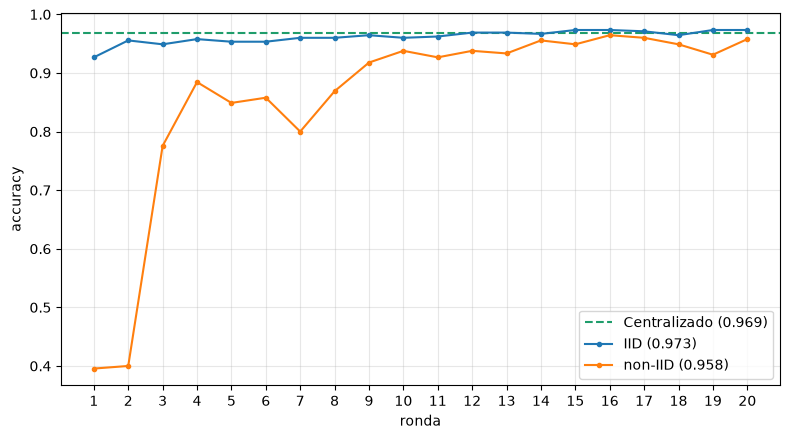

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4.5))
plt.axhline(acc_central, ls="--", color="#1F9D6B", label=f"Centralizado ({acc_central:.3f})")
plt.plot(range(1,len(hist_iid)+1),  hist_iid,  "-o", ms=3, label=f"IID ({hist_iid[-1]:.3f})")
plt.plot(range(1,len(hist_niid)+1), hist_niid, "-o", ms=3, label=f"non-IID ({hist_niid[-1]:.3f})")
plt.xticks(range(1,len(hist_iid)+1))
plt.xlabel("ronda"); plt.ylabel("accuracy"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. (Opcional) Privacidad diferencial

Agrega ruido a los pesos agregados y mide cómo cae la accuracy.

In [7]:
def federado_dp(clientes, sigma, R=20, frac=0.4, epocas=25, lr=0.5):
    W,b=init_modelo(); K,m=len(clientes),max(1,int(frac*len(clientes)))
    for _ in range(R):
        sel=rng.choice(K,m,replace=False)
        ups=[entrenar_local(W,b,*clientes[i][:2],epocas,lr) for i in sel]
        W,b=fedavg(ups)
        W = W + rng.normal(0, sigma, W.shape)
        b = b + rng.normal(0, sigma, b.shape)
    return accuracy(W,b)

clientes = particionar_iid(K)
for sigma in [0, 0.05, 0.1, 0.2]:
    print(f"sigma={sigma:<4} accuracy={federado_dp(clientes, sigma):.3f}")

sigma=0    accuracy=0.973
sigma=0.05 accuracy=0.958
sigma=0.1  accuracy=0.929
sigma=0.2  accuracy=0.891


### Reflexión

- Pérdida al federar: con datos IID no se perdió accuracy: el federado llegó a 0.973 contra 0.969 del centralizado. Con non-IID se perdió poco en el resultado final (0.958, aprox 1 punto), pero tardó mucho más en llegar.

- Estabilidad non-IID: la curva non-IID fue muy inestable. Arrancó en 0.40, tuvo caídas como la de la ronda 7 (0.80) y recién se estabilizó cerca de la ronda 10, mientras que la IID estuvo estable desde la ronda 2. Esto pasa porque cada cliente tiene solo 2 de los 10 dígitos y en cada ronda participan solo 2 clientes, entonces en cada ronda el modelo entrena con una parte distinta de los dígitos, y le va mejor en los que vio en esa ronda y peor en el resto.

- Medida de privacidad: en mi caso agregaría privacidad diferencial, sumando ruido a los pesos después de cada agregación, para proteger mejor los datos de cada hospital. El costo sería una pérdida de accuracy. En digits, con sigma = 0.2 bajó de 0.973 a 0.891. Con mis datos la pérdida podría ser distinta, así que habría que medirla antes de elegir cuánto ruido agregar.

- Federado orgánico o forzado: en mi proyecto actual sería forzado, porque el modelo se entrena con un único dataset público que ya está centralizado. Sería orgánico si los datos vinieran de distintos hospitales, ya que cada uno tendría sus propios pacientes y no podría compartir sus datos por privacidad y regulación.